# Le Miel et les Abeilles

Ce projet est une simulation de l'optimisation du chemin de 101 abeilles pour atteindre différentes fleurs et retourner à la ruche. Nous utilisons un algorithme génétique qui sélectionne les meilleures abeilles pour la reproduction et introduit des mutations pour explorer de nouvelles solutions. L’objectif est de trouver l’ordre de visite qui minimise la distance totale parcourue.

## Chargement des données

In [1]:
import csv
import matplotlib.pyplot as plt
from main import load_data
from beehive import Beehive
from config import FLOWERS_PATH

flowers = load_data(FLOWERS_PATH)
print(len(flowers))

50


L'abeille commence son voyage à la ruche, elle a un ordre de visite des 50 fleurs. L'objectif est d'optimiser la qualité de ce trajet en minimisant la distance totale parcourue.

## Comparaison des taux de mutation

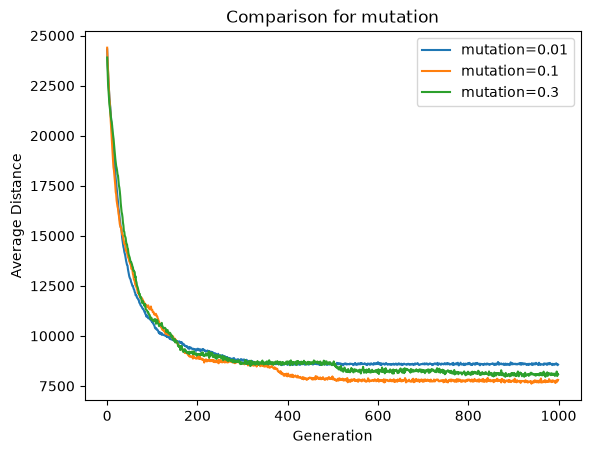

In [3]:
from main import plot_comparison

plot_comparison(flowers, "mutation", [0.01, 0.1, 0.3])

On observe que la courbe 0.01 plafonne à une distance plus élevée que les autres : la mutation est trop rare pour explorer de meilleures solutions. Les courbes 0.1 et 0.3 convergent vers des distances similaires, mais 0.3 n'apporte pas de gain supplémentaire et introduit plus de variations inutiles. On retient donc 0.1 comme bon compromis entre exploration et stabilité.

## Comparaison des taux de sélection

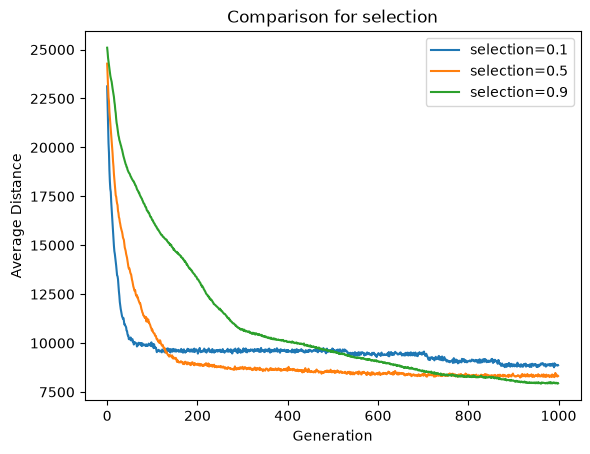

In [5]:
plot_comparison(flowers, "selection", [0.1, 0.5, 0.9])

On peut observer que la courbe de sélection 0.1 a peu de diversité, elle descend rapidement mais stagne trop haut. La sélection 0.9 a une convergence lente mais atteint une distance plus faible. La sélection 0.5 est un bon compromis entre exploration et exploitation, elle converge rapidement vers une distance faible.

## Chemin de la meilleure abeille

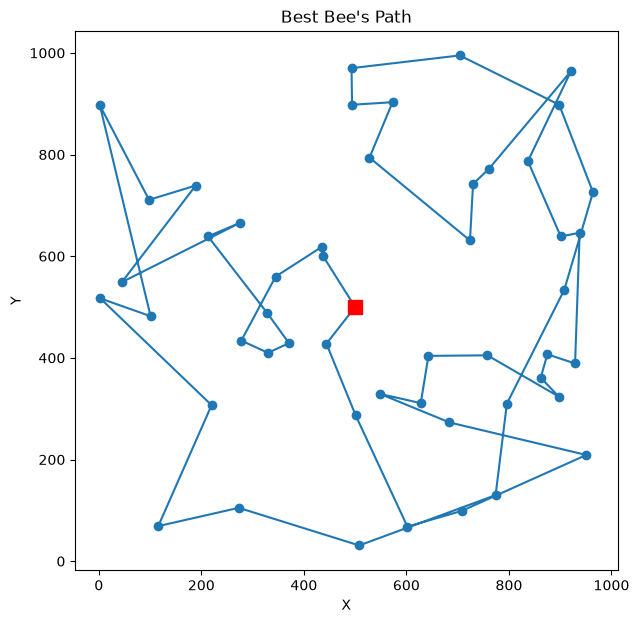

In [10]:
from main import run_beehive

b, history = run_beehive(flowers, mutation_rate=0.1, selection_rate=0.5)
best = b.get_best_bee()
xs = [b.beehive_position[0]] + [flower[0] for flower in best.path] + [b.beehive_position[0]]
ys = [b.beehive_position[1]] + [flower[1] for flower in best.path] + [b.beehive_position[1]]
plt.figure(figsize=(7, 7))
plt.plot(xs, ys, 'o-')
plt.scatter(*b.beehive_position, color='red', label='Beehive', s=100, zorder=5, marker='s')
plt.xlabel('X')
plt.ylabel('Y')
plt.title("Best Bee's Path")
plt.show()

Pour le meilleur chemin trouvé, on peut visualiser le trajet de l'abeille à travers les fleurs et la ruche. Cela permet de comprendre comment l'algorithme a optimisé le parcours pour minimiser la distance totale. Après avoir sélectionné les meilleures abeilles, croisé les meilleures solution, introduit les mutations de ces dernières en prenant en compte la reine des abeilles pour l'élitisme, on retient les paramètres de mutation 0.1 et de sélection 0.5 pour obtenir un bon compromis entre exploration et exploitation, permettant ainsi d'atteindre une distance minimale plus rapidement. Résultat final : La colonie converge vers un trajet court et le chemin de la meilleure abeille est visualisé sur le graphique ci-dessus.